In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ECGCNNv2(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            # Bloco 1
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Bloco 2
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Bloco 3
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Bloco 4
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)  # 🔑 independe do tamanho do sinal
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


Device: cuda
Epoch 01 | Train Loss: 789.104 | Val Acc: 0.7269
Epoch 02 | Train Loss: 419.548 | Val Acc: 0.8259
Epoch 03 | Train Loss: 307.838 | Val Acc: 0.8244
Epoch 04 | Train Loss: 265.306 | Val Acc: 0.8013
Epoch 05 | Train Loss: 236.567 | Val Acc: 0.7664
Epoch 06 | Train Loss: 226.763 | Val Acc: 0.7881
Epoch 07 | Train Loss: 205.106 | Val Acc: 0.8068
Epoch 08 | Train Loss: 192.139 | Val Acc: 0.8807
Epoch 09 | Train Loss: 179.447 | Val Acc: 0.9115
Epoch 10 | Train Loss: 172.491 | Val Acc: 0.9049
Epoch 11 | Train Loss: 168.811 | Val Acc: 0.5715
Epoch 12 | Train Loss: 175.042 | Val Acc: 0.9142
Epoch 13 | Train Loss: 156.145 | Val Acc: 0.8400
Epoch 14 | Train Loss: 152.599 | Val Acc: 0.9210
Epoch 15 | Train Loss: 147.779 | Val Acc: 0.9037


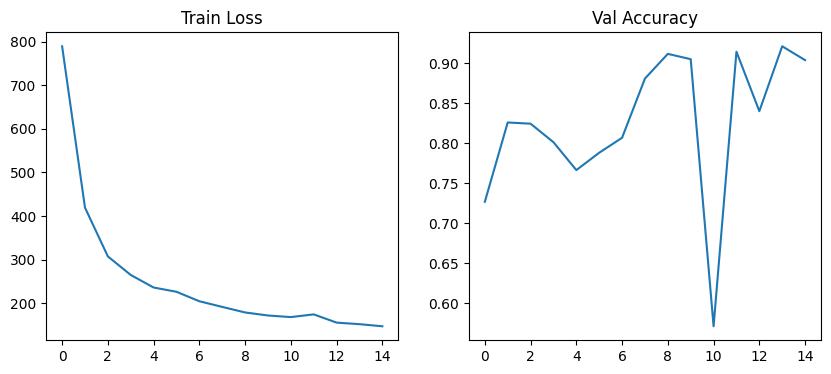

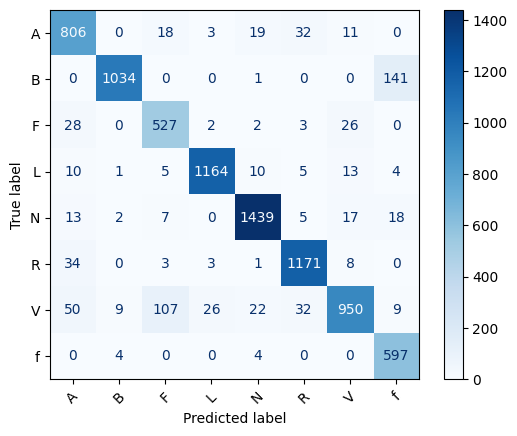

In [2]:
# ===============================
# IMPORTS
# ===============================
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight


# ===============================
# CONFIGURAÇÕES GERAIS
# ===============================
DATASET_ROOT = "dataset_split_2"
CHANNEL_COL = "channel_0"
FIXED_LENGTH = 600
BATCH_SIZE = 64
EPOCHS = 15
LR = 1e-3

CLASS_MAP = {
    "A": 0,
    "B": 1,
    "F": 2,
    "L": 3,
    "N": 4,
    "R": 5,
    "V": 6,
    "f": 7
}


# ===============================
# DATASET
# ===============================
class ECGDataset(Dataset):
    def __init__(self, root_dir, class_map):
        self.files = []
        self.labels = []
        self.class_map = class_map

        for cls in class_map:
            cls_dir = os.path.join(root_dir, cls)
            if not os.path.exists(cls_dir):
                continue

            for f in glob.glob(os.path.join(cls_dir, "*.csv")):
                self.files.append(f)
                self.labels.append(class_map[cls])

    def __len__(self):
        return len(self.files)

    def _pad_or_crop(self, x):
        if len(x) > FIXED_LENGTH:
            return x[:FIXED_LENGTH]
        if len(x) < FIXED_LENGTH:
            return np.pad(x, (0, FIXED_LENGTH - len(x)))
        return x

    def __getitem__(self, idx):
        df = pd.read_csv(self.files[idx])
        x = df[CHANNEL_COL].values.astype(np.float32)
        x = self._pad_or_crop(x)

        x = torch.tensor(x).unsqueeze(0)  # (1, L)
        y = torch.tensor(self.labels[idx])

        return x, y


# ===============================
# MODELO CNN 1D
# ===============================
class ECGCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(1, 16, 7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, 5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, 3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.net(x)
        x = x.squeeze(-1)
        return self.fc(x)


# ===============================
# TREINAMENTO
# ===============================
def train_model(model, train_loader, val_loader, device, class_weights):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    history = {"train_loss": [], "val_acc": []}

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                pred = model(x).argmax(dim=1)
                correct += (pred == y).sum().item()
                total += y.size(0)

        acc = correct / total
        history["train_loss"].append(total_loss)
        history["val_acc"].append(acc)

        print(f"Epoch {epoch+1:02d} | Train Loss: {total_loss:.3f} | Val Acc: {acc:.4f}")

    return history


# ===============================
# PLOTS
# ===============================
def plot_history(history):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(history["train_loss"])
    plt.title("Train Loss")

    plt.subplot(1,2,2)
    plt.plot(history["val_acc"])
    plt.title("Val Accuracy")

    plt.show()


# ===============================
# MATRIZ DE CONFUSÃO
# ===============================
def evaluate_confusion_matrix(model, loader, device):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            pred = model(x).argmax(dim=1).cpu().numpy()

            y_true.extend(y.numpy())
            y_pred.extend(pred)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_MAP.keys())
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.show()


# ===============================
# MAIN
# ===============================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    train_ds = ECGDataset(f"{DATASET_ROOT}/train", CLASS_MAP)
    val_ds   = ECGDataset(f"{DATASET_ROOT}/val", CLASS_MAP)
    test_ds  = ECGDataset(f"{DATASET_ROOT}/test", CLASS_MAP)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    y_train = np.array(train_ds.labels)
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train),
        y=y_train
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    model = ECGCNN(num_classes=len(CLASS_MAP)).to(device)

    history = train_model(model, train_loader, val_loader, device, class_weights)

    plot_history(history)

    evaluate_confusion_matrix(model, test_loader, device)


Device: cuda
Epoch 01 | Train Loss: 399.521 | Val Acc: 0.7159
Epoch 02 | Train Loss: 176.832 | Val Acc: 0.9061
Epoch 03 | Train Loss: 135.215 | Val Acc: 0.9199
Epoch 04 | Train Loss: 116.892 | Val Acc: 0.9424
Epoch 05 | Train Loss: 104.439 | Val Acc: 0.9430
Epoch 06 | Train Loss: 96.595 | Val Acc: 0.9443
Epoch 07 | Train Loss: 87.174 | Val Acc: 0.9472
Epoch 08 | Train Loss: 83.725 | Val Acc: 0.9397
Epoch 09 | Train Loss: 80.170 | Val Acc: 0.9379
Epoch 10 | Train Loss: 73.517 | Val Acc: 0.9621
Epoch 11 | Train Loss: 70.290 | Val Acc: 0.9365
Epoch 12 | Train Loss: 68.498 | Val Acc: 0.9570
Epoch 13 | Train Loss: 75.963 | Val Acc: 0.9521
Epoch 14 | Train Loss: 85.276 | Val Acc: 0.9608
Epoch 15 | Train Loss: 64.732 | Val Acc: 0.9658


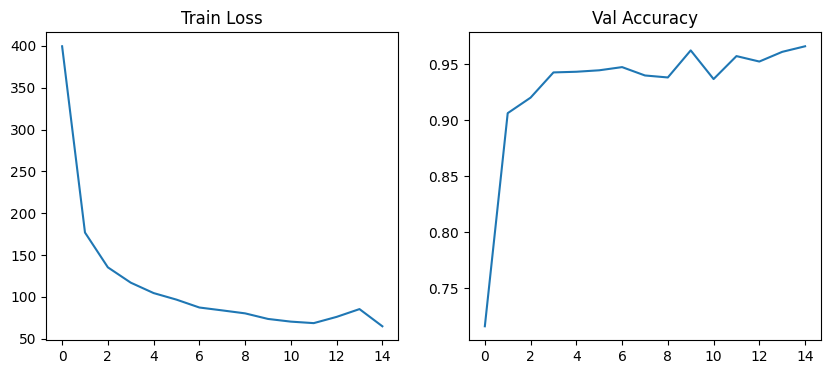

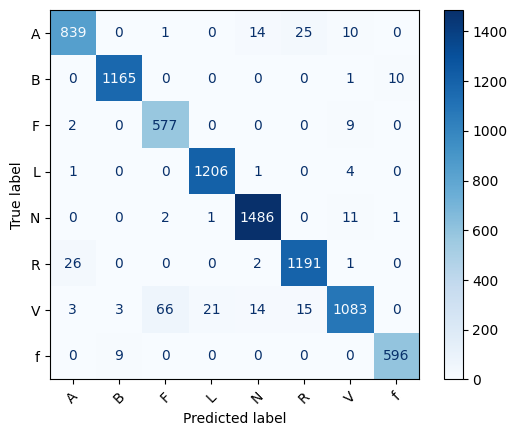

In [3]:
# ===============================
# MAIN
# ===============================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    train_ds = ECGDataset(f"{DATASET_ROOT}/train", CLASS_MAP)
    val_ds   = ECGDataset(f"{DATASET_ROOT}/val", CLASS_MAP)
    test_ds  = ECGDataset(f"{DATASET_ROOT}/test", CLASS_MAP)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    y_train = np.array(train_ds.labels)
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train),
        y=y_train
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    model = ECGCNNv2(num_classes=len(CLASS_MAP)).to(device)

    history = train_model(model, train_loader, val_loader, device, class_weights)

    plot_history(history)

    evaluate_confusion_matrix(model, test_loader, device)